In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr

import jax
import jax.numpy as jnp
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.bijectors as tfb

In [2]:
# ========
# 1. SETUP
# ========

# Constants & Labels
param_names = ["Blue Bonnet", "Fleischmanns", "House", "Generic", "Shed Spread", "log(price)"]
demo_names = ["Intercept", "log(Income)", "Family size"]
n_demos = len(demo_names)
k_dim = len(param_names)

In [3]:
# ===============
# 2. LOAD SAMPLES
# ===============
data_dir = "Data"
liesel_path = os.path.join(data_dir, "liesel_posterior_samples_demeaned.pkl")
bayesm_path = os.path.join(data_dir, "bayesm_output_margarine_demeaned.RData")

# Load Liesel Samples
print(f"Loading Liesel samples from {liesel_path}")
with open(liesel_path, "rb") as f:
    liesel_samples = pickle.load(f)

# Load Bayesm Samples
print(f"Loading Bayesm samples from {bayesm_path}")
bayesm_res = pyreadr.read_r(bayesm_path)

Loading Liesel samples from Data\liesel_posterior_samples_demeaned.pkl
Loading Bayesm samples from Data\bayesm_output_margarine_demeaned.RData


In [4]:
# ==============================
# 3. DATA PROCESSING & RESHAPING
# ==============================
print("Standardizing array shapes for comparison...")

# --- Prepare Liesel Arrays ---
# Delta & Mu: Flatten chains/draws to (Total_Draws, Demos, Params)
liesel_delta_full = liesel_samples["Delta"].reshape(-1, n_demos, k_dim)
liesel_mu = liesel_delta_full[:, 0, :]  # Base intercepts

# Beta: Flatten chains/draws to (Total_Draws, Units, Params)
liesel_beta_raw = liesel_samples["beta_i"]
if liesel_beta_raw.ndim == 4:
    n_chains, n_draws, n_units, _ = liesel_beta_raw.shape
    liesel_beta_full = liesel_beta_raw.reshape(n_chains * n_draws, n_units, k_dim)
else:
    liesel_beta_full = liesel_beta_raw
    n_units = liesel_beta_full.shape[1]

# --- Prepare Bayesm Arrays ---
# Mu
bayesm_mu = bayesm_res['mu_draws_df'].values
n_bayesm_draws = bayesm_mu.shape[0]

# Delta: Combine Mu and Delta into a single (Draws, Demos, Params) array
bayesm_delta_df = bayesm_res['delta_draws_df']
bayesm_delta_only = np.zeros((n_bayesm_draws, 2, k_dim)) 
for i in range(n_bayesm_draws):
    bayesm_delta_only[i] = bayesm_delta_df.values[i].reshape((2, k_dim), order='C')

bayesm_mu_expanded = bayesm_mu[:, None, :] # Add dimension to match (Draws, 1, Params)
bayesm_delta_full = np.concatenate([bayesm_mu_expanded, bayesm_delta_only], axis=1)

# Beta: Reshape Fortran-ordered dataframe back to (Draws, Units, Params)
bayesm_beta_df = bayesm_res['beta_reordered']
n_samples_r = bayesm_beta_df.size // (n_units * k_dim)
bayesm_beta_full = bayesm_beta_df.values.reshape((n_units, n_samples_r, k_dim), order='F').transpose(1, 0, 2)

print(f"Liesel Shapes -> Mu: {liesel_mu.shape}, Delta: {liesel_delta_full.shape}, Beta: {liesel_beta_full.shape}")
print(f"Bayesm Shapes -> Mu: {bayesm_mu.shape}, Delta: {bayesm_delta_full.shape}, Beta: {bayesm_beta_full.shape}")

Standardizing array shapes for comparison...
Liesel Shapes -> Mu: (10000, 6), Delta: (10000, 3, 6), Beta: (10000, 313, 6)
Bayesm Shapes -> Mu: (40000, 6), Delta: (40000, 3, 6), Beta: (40000, 313, 6)



=== Global Parameters (Baseline Means) Summary Table ===


,Parameter,Bayesm_Mean,Liesel_Mean,Diff_Mean,Bayesm_Std,Liesel_Std
0,Blue Bonnet,-1.1267,-1.1390,0.0122,0.1310,0.1275
1,Fleischmanns,-3.4620,-3.6205,0.1585,0.6944,0.7678
2,House,-2.4658,-2.4652,-0.0007,0.1924,0.1881
3,Generic,-5.0178,-4.9892,-0.0286,0.3000,0.3134
4,Shed Spread,-1.7611,-1.7505,-0.0107,0.3726,0.3395
5,log(price),-4.0304,-4.0330,0.0026,0.1797,0.1728



=== Posterior distribution of Delta (Liesel) ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
Intercept,-1.14 (0.13),-3.62 (0.77),-2.47 (0.19),-4.99 (0.31),-1.75 (0.34),-4.03 (0.17)
log(Income),0.06 (0.22),0.80 (0.69),0.03 (0.30),-0.50 (0.40),-0.63 (0.43),-0.30 (0.29)
Family size,-0.03 (0.10),-0.80 (0.34),0.24 (0.14),0.60 (0.19),0.05 (0.20),0.12 (0.13)



=== Posterior distribution of Delta (Bayesm) ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
Intercept,-1.13 (0.13),-3.46 (0.69),-2.47 (0.19),-5.02 (0.30),-1.76 (0.37),-4.03 (0.18)
log(Income),0.05 (0.22),0.80 (0.68),0.04 (0.31),-0.53 (0.42),-0.64 (0.44),-0.29 (0.30)
Family size,-0.03 (0.10),-0.76 (0.33),0.25 (0.14),0.60 (0.18),0.05 (0.21),0.12 (0.12)



=== DIFFERENCE in Delta (Bayesm - Liesel) ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
Intercept,0.012 (0.004),0.159 (-0.073),-0.001 (0.004),-0.029 (-0.013),-0.011 (0.033),0.003 (0.007)
log(Income),-0.006 (-0.002),0.003 (-0.013),0.002 (0.001),-0.022 (0.016),-0.007 (0.009),0.009 (0.013)
Family size,-0.002 (-0.001),0.041 (-0.009),0.001 (0.003),0.002 (-0.001),0.005 (0.001),-0.008 (-0.002)


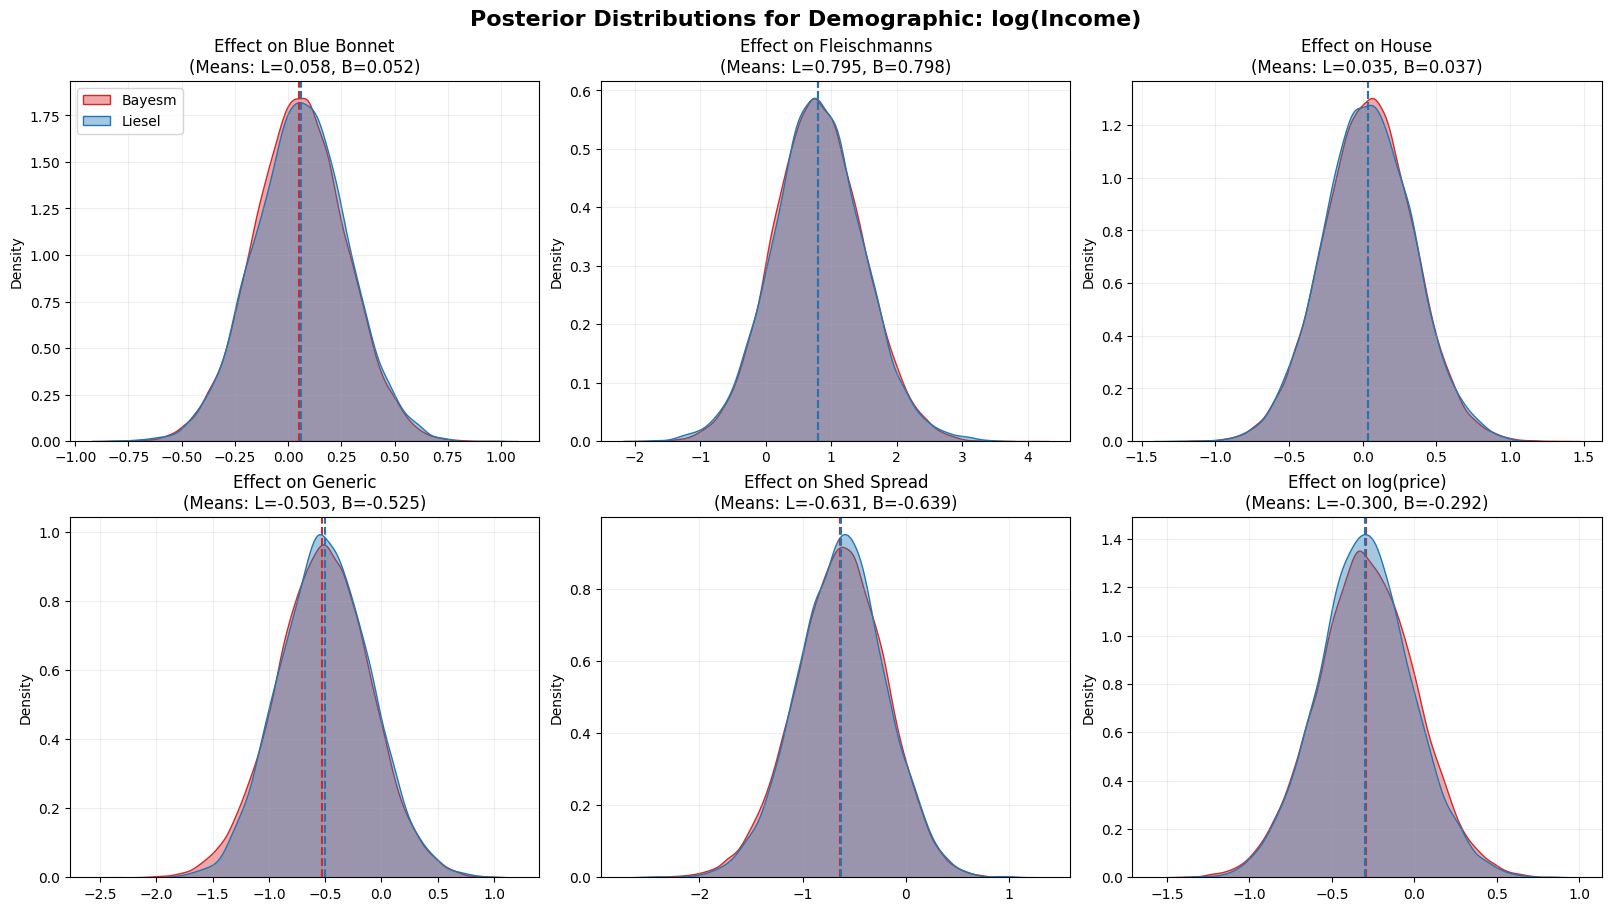

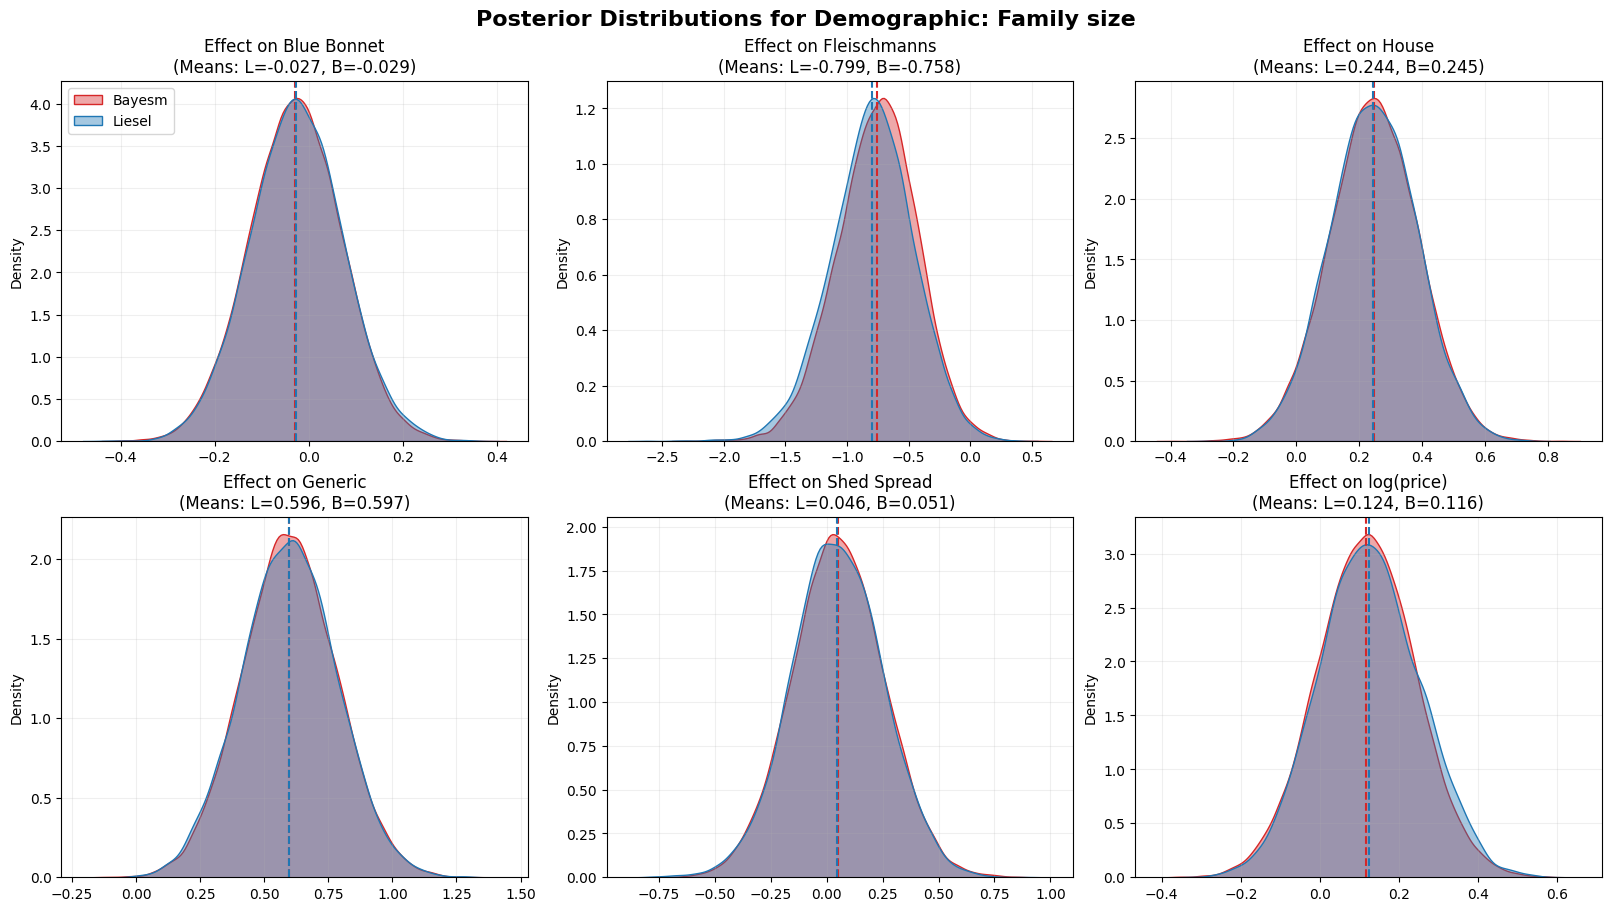

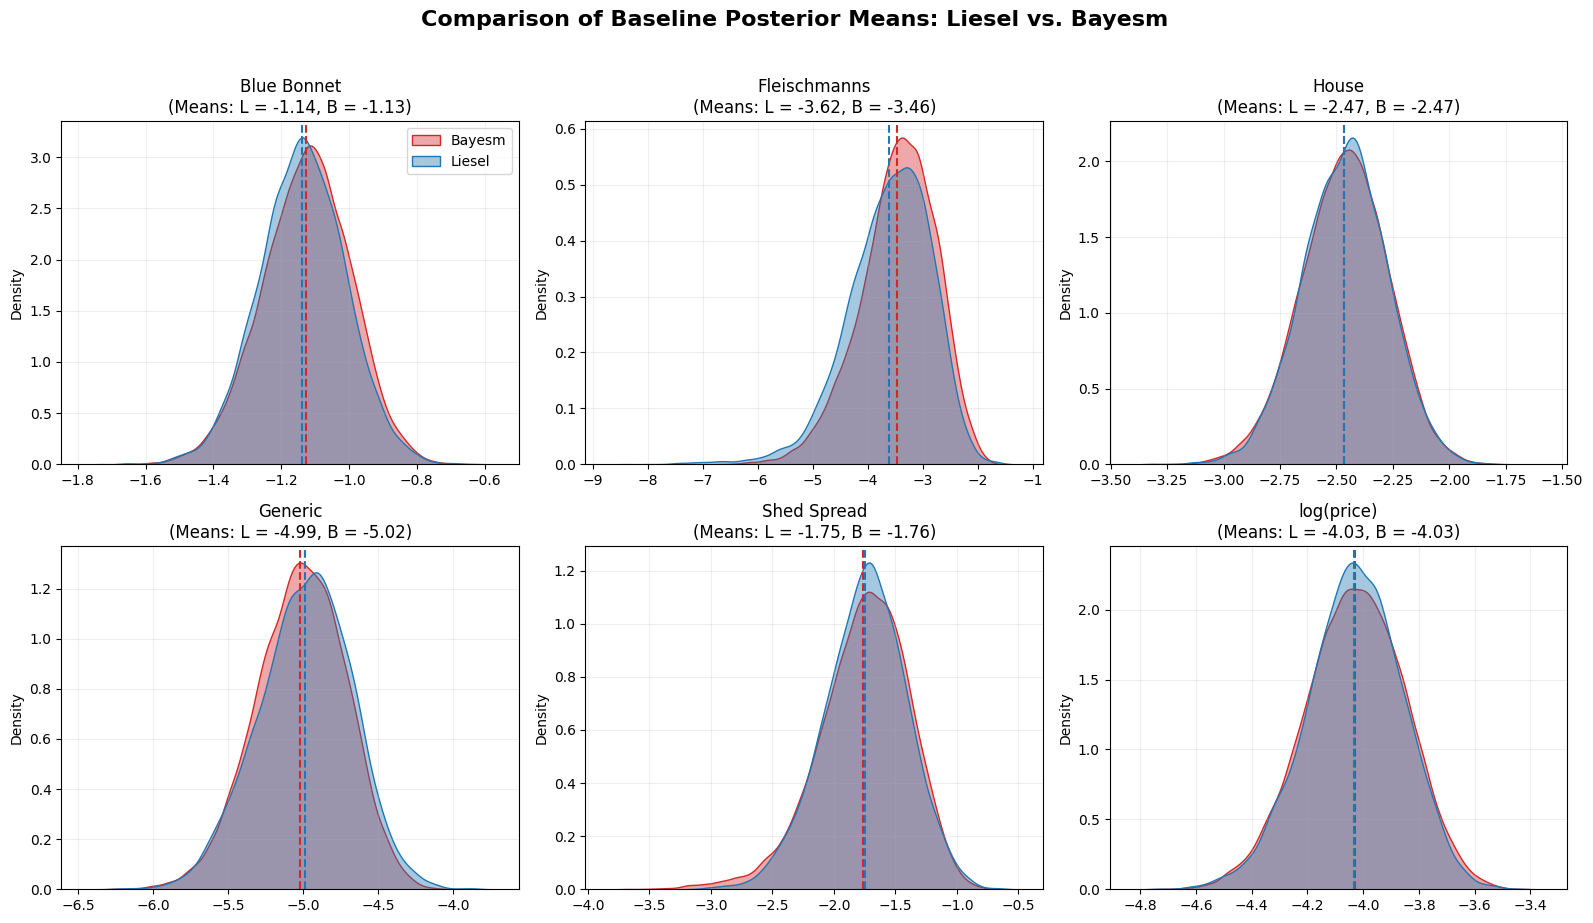

In [5]:
# ============================================
# 4. GLOBAL PARAMETERS: BASELINE MEANS & DELTA
# ============================================

# --- Summary Table ---
def create_summary_table(r_mu, l_mu, p_names):
    return pd.DataFrame({
        'Parameter': p_names,
        'Bayesm_Mean': r_mu.mean(axis=0),
        'Liesel_Mean': l_mu.mean(axis=0),
        'Diff_Mean': r_mu.mean(axis=0) - l_mu.mean(axis=0),
        'Bayesm_Std': r_mu.std(axis=0),
        'Liesel_Std': l_mu.std(axis=0)
    }).round(4)

print("\n=== Global Parameters (Baseline Means) Summary Table ===")
display(create_summary_table(bayesm_mu, liesel_mu, param_names))

# --- Delta Tables ---
def generate_delta_table(delta_draws, p_names, d_names):
    mean, std = np.mean(delta_draws, axis=0), np.std(delta_draws, axis=0)
    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]: .2f} ({std[i, j]:.2f})"
    return df

def generate_delta_diff_table(b_delta, l_delta, p_names, d_names):
    """Calculates Bayesm - Liesel differences for Delta means and standard deviations."""
    b_mean, b_std = np.mean(b_delta, axis=0), np.std(b_delta, axis=0)
    l_mean, l_std = np.mean(l_delta, axis=0), np.std(l_delta, axis=0)
    
    diff_mean = b_mean - l_mean
    diff_std = b_std - l_std
    
    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{diff_mean[i, j]: .3f} ({diff_std[i, j]:.3f})"
    return df

print("\n=== Posterior distribution of Delta (Liesel) ===")
display(generate_delta_table(liesel_delta_full, param_names, demo_names))
print("\n=== Posterior distribution of Delta (Bayesm) ===")
display(generate_delta_table(bayesm_delta_full, param_names, demo_names))
print("\n=== DIFFERENCE in Delta (Bayesm - Liesel) ===")
display(generate_delta_diff_table(bayesm_delta_full, liesel_delta_full, param_names, demo_names))


# --- Distributions for demographic effects ---
def plot_delta_distributions(b_delta, l_delta, demo_idx, demo_name, param_names):
    """
    Plots the posterior distributions for a specific demographic variable
    across all parameters.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    fig.suptitle(f"Posterior Distributions for Demographic: {demo_name}", fontsize=16, fontweight='bold')
    
    for i, (ax, param) in enumerate(zip(axes.flatten(), param_names)):
        # Extract the draws for the specific demographic (demo_idx) and parameter (i)
        b_vals = b_delta[:, demo_idx, i]
        l_vals = l_delta[:, demo_idx, i]
        
        # Plot Bayesm FIRST (back)
        sns.kdeplot(b_vals, ax=ax, fill=True, color="#d62728", alpha=0.4, label="Bayesm")
        # Plot Liesel SECOND (front)
        sns.kdeplot(l_vals, ax=ax, fill=True, color="#1f77b4", alpha=0.4, label="Liesel")
        
        # Add mean lines
        ax.axvline(np.mean(b_vals), color="#d62728", linestyle="--")
        ax.axvline(np.mean(l_vals), color="#1f77b4", linestyle="--")
        
        ax.set_title(f"Effect on {param}\n(Means: L={np.mean(l_vals):.3f}, B={np.mean(b_vals):.3f})")
        ax.grid(True, alpha=0.2)
        if i == 0: ax.legend(loc="upper left")

    plt.show()

# Plot distributions for log(Income) (Index 1)
plot_delta_distributions(
    bayesm_delta_full, 
    liesel_delta_full, 
    demo_idx=1, 
    demo_name="log(Income)", 
    param_names=param_names
)

# Plot distributions for Family size (Index 2)
plot_delta_distributions(
    bayesm_delta_full, 
    liesel_delta_full, 
    demo_idx=2, 
    demo_name="Family size", 
    param_names=param_names
)


# --- KDE Plots for Baseline Means ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, (ax, param) in enumerate(zip(axes.flatten(), param_names)):
    # Plot Bayesm FIRST so it goes to the back
    sns.kdeplot(bayesm_mu[:, i], ax=ax, fill=True, color="#d62728", alpha=0.4, label="Bayesm")
    # Plot Liesel SECOND so it goes in front
    sns.kdeplot(liesel_mu[:, i], ax=ax, fill=True, color="#1f77b4", alpha=0.4, label="Liesel")
    
    ax.axvline(np.mean(bayesm_mu[:, i]), color="#d62728", linestyle="--")
    ax.axvline(np.mean(liesel_mu[:, i]), color="#1f77b4", linestyle="--")
    ax.set_title(f"{param}\n(Means: L = {np.mean(liesel_mu[:, i]):.2f}, B = {np.mean(bayesm_mu[:, i]):.2f})")
    ax.grid(True, alpha=0.2)
    if i == 0: ax.legend(loc="upper right")

plt.suptitle("Comparison of Baseline Posterior Means: Liesel vs. Bayesm", y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ====================================
# 5. COVARIANCE AND CORRELATION TABLES
# ====================================

def format_cov_corr_table(std_draws, corr_draws, p_names):
    std_mean, std_sd = np.mean(std_draws, axis=0), np.std(std_draws, axis=0)
    corr_mean, corr_sd = np.mean(corr_draws, axis=0), np.std(corr_draws, axis=0)
    
    df = pd.DataFrame(index=p_names, columns=p_names)
    for i in range(len(p_names)):
        for j in range(len(p_names)):
            if i == j: df.iloc[i, j] = f"{std_mean[i]:.2f} ({std_sd[i]:.2f})"
            elif j > i: df.iloc[i, j] = f"{corr_mean[i, j]:.2f} ({corr_sd[i, j]:.2f})"
            else: df.iloc[i, j] = ""
    return df

def format_cov_corr_diff_table(b_stds, l_stds, b_corrs, l_corrs, p_names):
    """Calculates Bayesm - Liesel differences for SDs and Correlations."""
    b_std_m, b_std_sd = np.mean(b_stds, axis=0), np.std(b_stds, axis=0)
    l_std_m, l_std_sd = np.mean(l_stds, axis=0), np.std(l_stds, axis=0)
    
    b_corr_m, b_corr_sd = np.mean(b_corrs, axis=0), np.std(b_corrs, axis=0)
    l_corr_m, l_corr_sd = np.mean(l_corrs, axis=0), np.std(l_corrs, axis=0)
    
    diff_std_m = b_std_m - l_std_m
    diff_std_sd = b_std_sd - l_std_sd
    diff_corr_m = b_corr_m - l_corr_m
    diff_corr_sd = b_corr_sd - l_corr_sd
    
    df = pd.DataFrame(index=p_names, columns=p_names)
    for i in range(len(p_names)):
        for j in range(len(p_names)):
            if i == j: 
                df.iloc[i, j] = f"{diff_std_m[i]:.3f} ({diff_std_sd[i]:.3f})"
            elif j > i: 
                df.iloc[i, j] = f"{diff_corr_m[i, j]:.3f} ({diff_corr_sd[i, j]:.3f})"
            else: 
                df.iloc[i, j] = ""
    return df

# Liesel Covariance logic
latent_samples = liesel_samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
bijector = tfb.FillScaleTriL()
v_latent_to_cov = jax.vmap(lambda v: jnp.linalg.inv(bijector.forward(v) @ bijector.forward(v).T))
liesel_cov_draws = np.array(v_latent_to_cov(latent_samples))
l_stds = np.sqrt(np.diagonal(liesel_cov_draws, axis1=1, axis2=2))
l_corrs = liesel_cov_draws / (l_stds[:, :, None] * l_stds[:, None, :])

# Bayesm Covariance logic
bayesm_cov_draws = bayesm_res['cov_draws_df'].values.reshape((-1, k_dim, k_dim), order='C').transpose((0, 2, 1))
b_stds = np.sqrt(np.diagonal(bayesm_cov_draws, axis1=1, axis2=2))
b_corrs = bayesm_cov_draws / (b_stds[:, :, None] * b_stds[:, None, :])

print("\n=== Correlations and standard deviations of betas (Liesel) ===")
display(format_cov_corr_table(l_stds, l_corrs, param_names))
print("\n=== Correlations and standard deviations of betas (Bayesm) ===")
display(format_cov_corr_table(b_stds, b_corrs, param_names))
print("\n=== DIFFERENCE in Corrs and SDs (Bayesm - Liesel) ===")
display(format_cov_corr_diff_table(b_stds, l_stds, b_corrs, l_corrs, param_names))


=== Correlations and standard deviations of betas (Liesel) ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
Blue Bonnet,1.54 (0.13),0.35 (0.14),0.42 (0.10),0.44 (0.10),0.27 (0.13),-0.10 (0.15)
Fleischmanns,,3.98 (0.63),0.25 (0.15),0.13 (0.17),0.08 (0.18),0.37 (0.18)
House,,,2.39 (0.19),0.84 (0.04),0.49 (0.10),-0.12 (0.15)
Generic,,,,2.96 (0.26),0.54 (0.11),-0.23 (0.15)
Shed Spread,,,,,3.01 (0.31),0.07 (0.16)
log(price),,,,,,1.43 (0.18)



=== Correlations and standard deviations of betas (Bayesm) ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
Blue Bonnet,2.93 (0.43),0.43 (0.21),0.64 (0.11),0.52 (0.11),0.26 (0.13),-0.06 (0.08)
Fleischmanns,,3.65 (0.53),-0.02 (0.17),-0.07 (0.15),-0.02 (0.14),0.20 (0.09)
House,,,3.28 (0.31),0.72 (0.06),0.36 (0.09),-0.06 (0.07)
Generic,,,,1.68 (0.26),0.37 (0.23),-0.12 (0.15)
Shed Spread,,,,,2.37 (0.34),0.17 (0.12)
log(price),,,,,,1.06 (0.20)



=== DIFFERENCE in Corrs and SDs (Bayesm - Liesel) ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
Blue Bonnet,1.382 (0.304),0.079 (0.063),0.215 (0.016),0.074 (0.011),-0.012 (0.000),0.047 (-0.072)
Fleischmanns,,-0.330 (-0.098),-0.266 (0.016),-0.202 (-0.020),-0.103 (-0.040),-0.173 (-0.091)
House,,,0.888 (0.124),-0.124 (0.025),-0.128 (-0.012),0.059 (-0.076)
Generic,,,,-1.282 (-0.003),-0.168 (0.127),0.104 (-0.010)
Shed Spread,,,,,-0.639 (0.026),0.106 (-0.039)
log(price),,,,,,-0.362 (0.015)


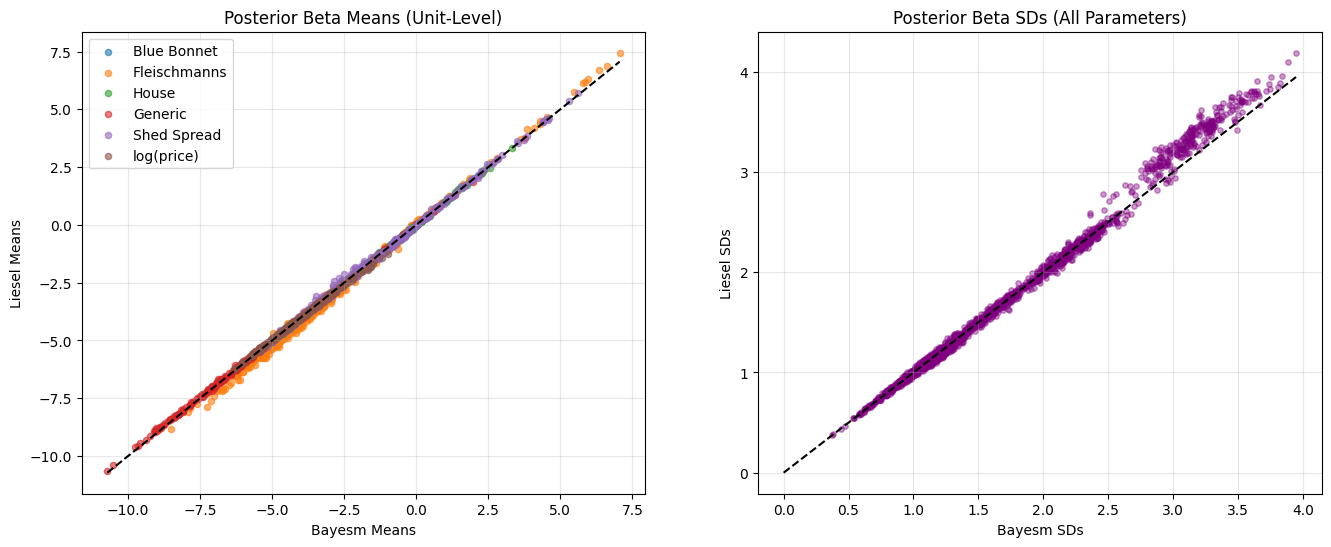

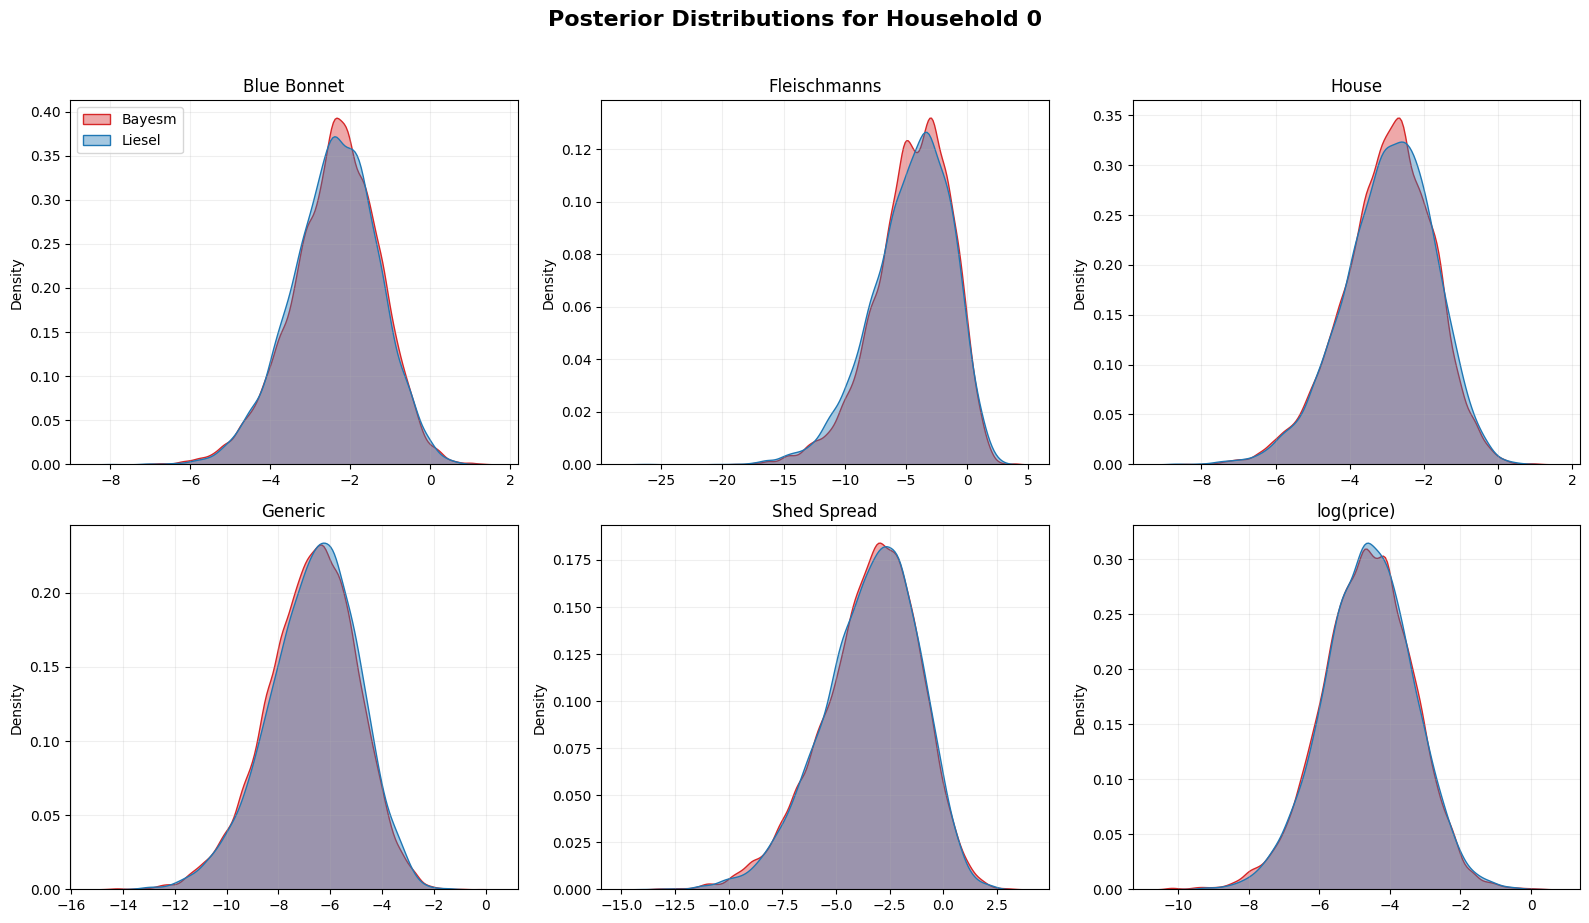

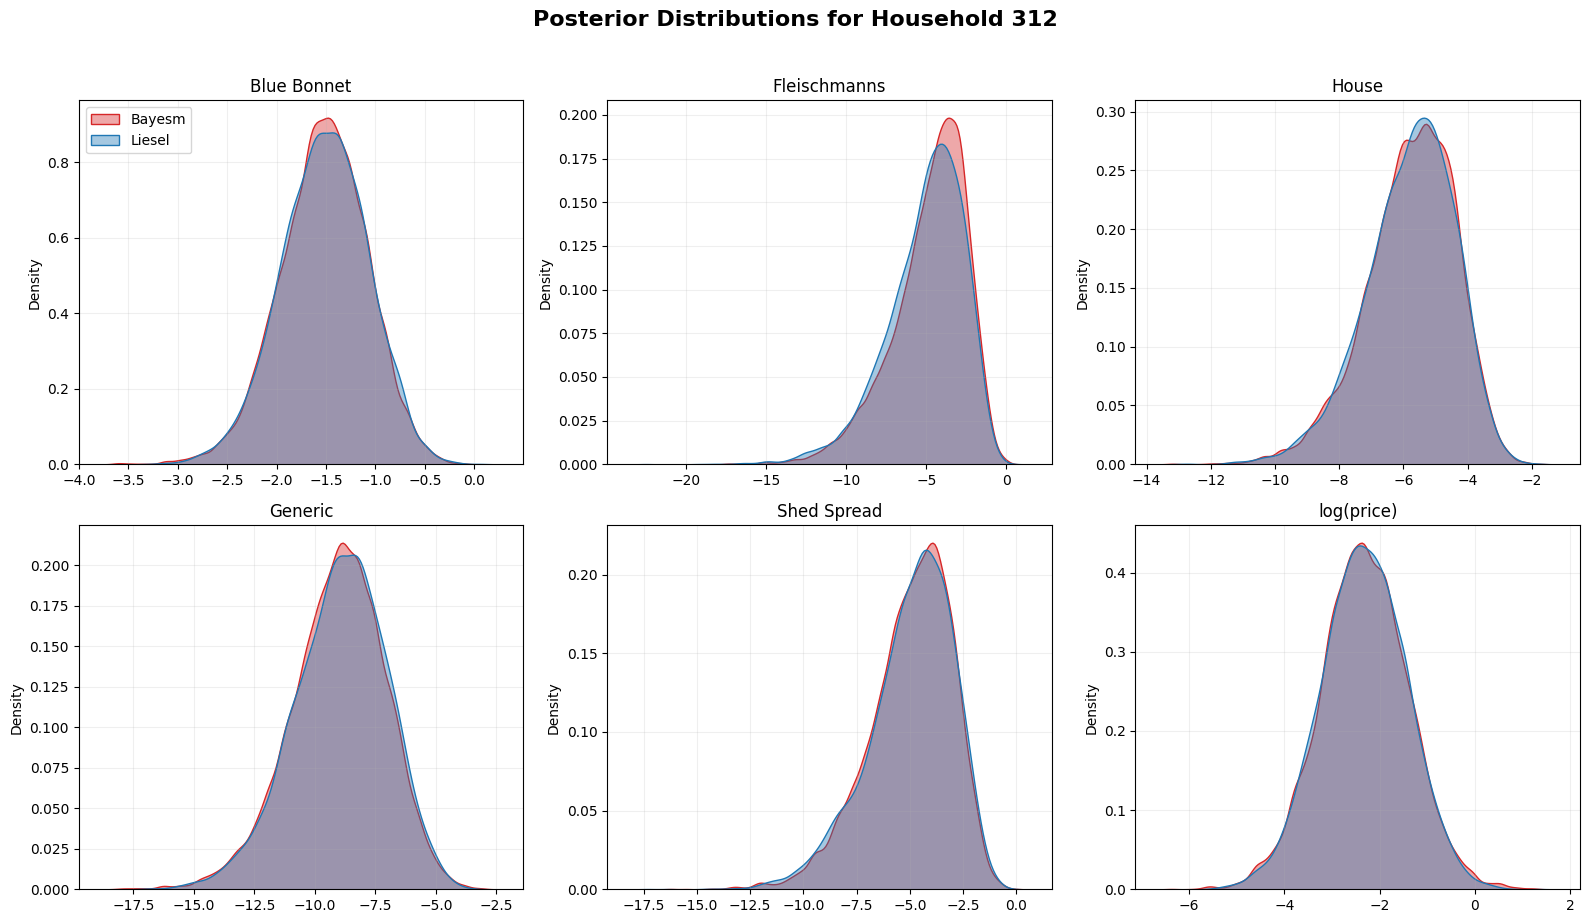

In [7]:
# ==================================
# 6. HOUSEHOLD HETEROGENEITY (BETAS)
# ==================================

# --- Parameter Recovery (Scatter Means & SDs) ---
r_beta_means = np.mean(bayesm_beta_full, axis=0)
l_beta_means = np.mean(liesel_beta_full, axis=0)

r_beta_sds = np.std(bayesm_beta_full, axis=0).flatten()
l_beta_sds = np.std(liesel_beta_full, axis=0).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean Scatter
for i, param in enumerate(param_names):
    axes[0].scatter(r_beta_means[:, i], l_beta_means[:, i], alpha=0.6, s=20, label=param)
axes[0].plot([r_beta_means.min(), r_beta_means.max()], [r_beta_means.min(), r_beta_means.max()], 'k--')
axes[0].set(title="Posterior Beta Means (Unit-Level)", xlabel="Bayesm Means", ylabel="Liesel Means")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# SD Scatter
axes[1].scatter(r_beta_sds, l_beta_sds, alpha=0.4, color='purple', s=15)
axes[1].plot([0, r_beta_sds.max()], [0, r_beta_sds.max()], 'k--')
axes[1].set(title="Posterior Beta SDs (All Parameters)", xlabel="Bayesm SDs", ylabel="Liesel SDs")
axes[1].grid(True, alpha=0.3)

plt.show()

# --- Pooled vs Individual Distributions Plotter ---
def plot_beta_distributions(r_data, l_data, param_names, title_prefix, is_pooled=False, color_l="#1f77b4", color_r="#d62728"):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for i, (ax, param) in enumerate(zip(axes.flatten(), param_names)):
        r_vals = r_data[:, i] if is_pooled else r_data[:, i]
        l_vals = l_data[:, i] if is_pooled else l_data[:, i]
        
        # Plot Bayesm FIRST so it goes to the back
        sns.kdeplot(r_vals, ax=ax, fill=True, color=color_r, alpha=0.4, label="Bayesm")
        # Plot Liesel SECOND so it goes in front
        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l, alpha=0.4, label="Liesel")
        
        ax.set_title(param, fontsize=12)
        ax.grid(True, alpha=0.2)
        if i == 0: ax.legend(loc="upper left")
        
    plt.suptitle(title_prefix, y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Individual Unit Plots (Unit 0 and Unit 312)
plot_beta_distributions(bayesm_beta_full[:, 0, :], liesel_beta_full[:, 0, :], param_names, "Posterior Distributions for Household 0")
plot_beta_distributions(bayesm_beta_full[:, -1, :], liesel_beta_full[:, -1, :], param_names, f"Posterior Distributions for Household {n_units-1}")

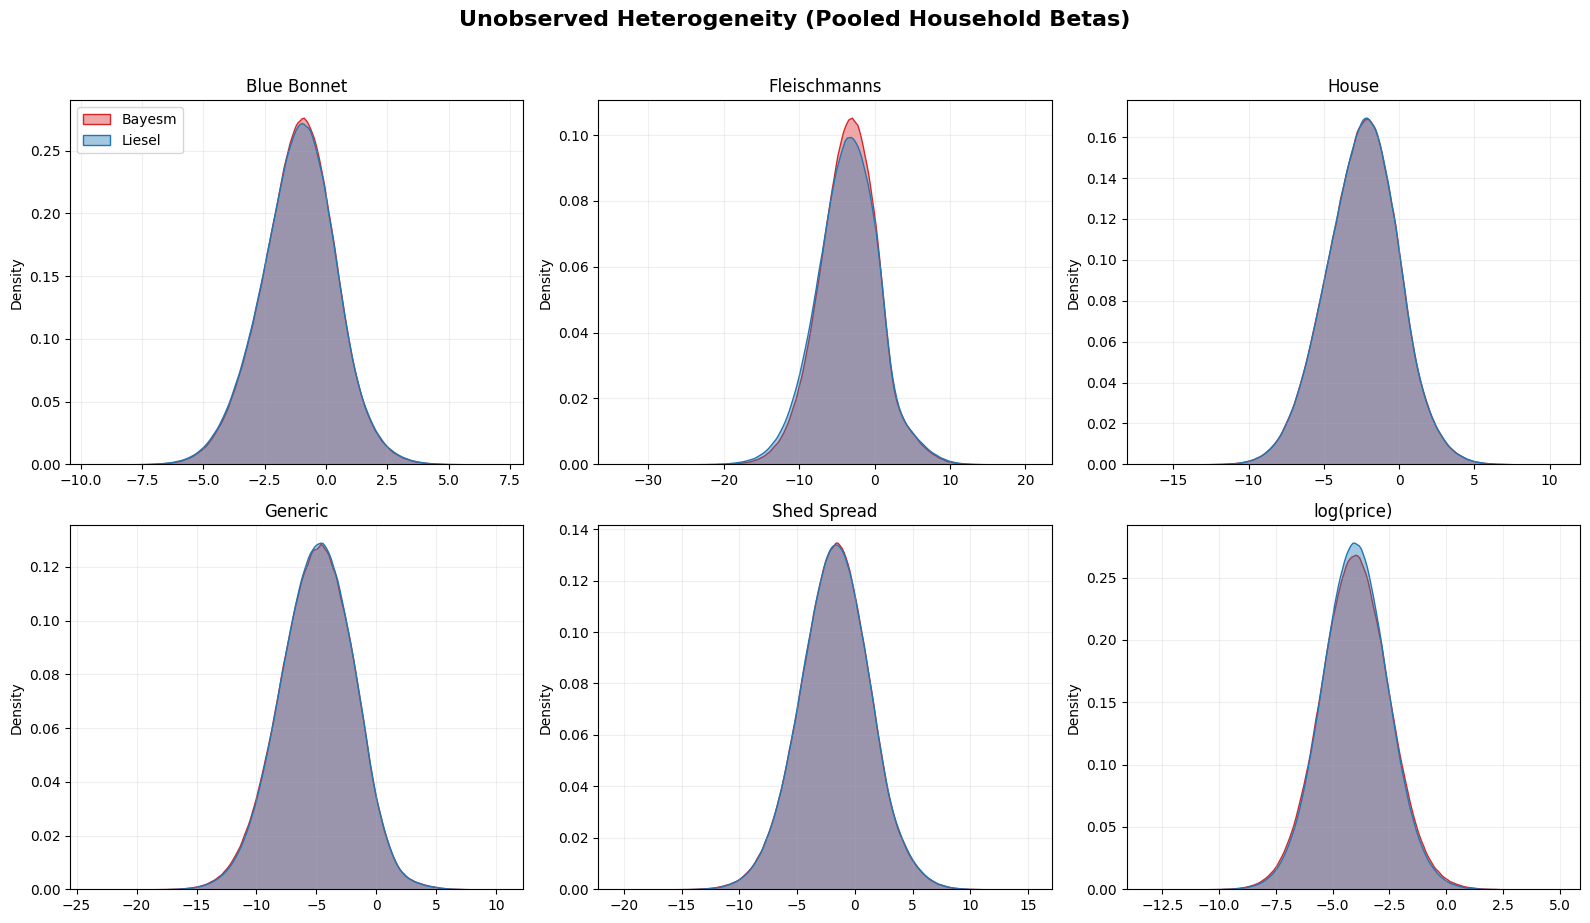

In [ ]:
# Pooled Plot (This take roughly 10min!)
plot_beta_distributions(
    bayesm_beta_full.reshape(-1, k_dim), 
    liesel_beta_full.reshape(-1, k_dim), 
    param_names, 
    "Pooled Household Betas", 
    is_pooled=True
)